In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('final_train.csv')
countries = pd.read_csv('data/countries.csv')
age_gender = pd.read_csv('data/age_gender_bkts.csv')

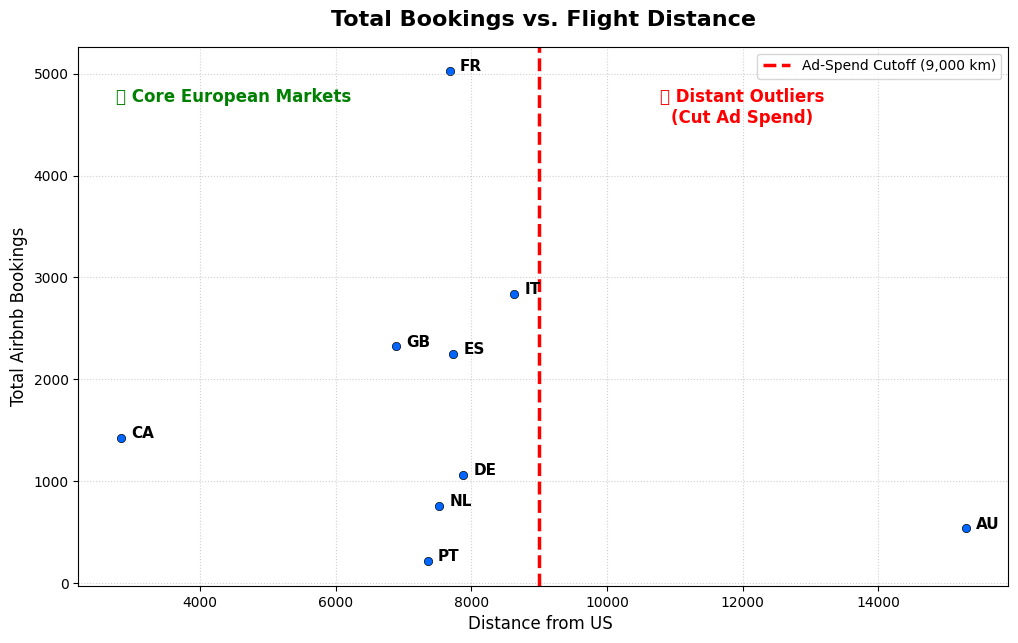

In [39]:

# 1. Filter out domestic (US) and non-bookings (NDF)
travelers = train[(train['country_destination'] != 'NDF') & 
                     (train['country_destination'] != 'US')]

# 2. Get booking volumes per country
booking_volumes = travelers['country_destination'].value_counts().reset_index()
booking_volumes.columns = ['country_destination', 'total_bookings']

# 3. Merge with countries.csv to get the distance
df_wall = pd.merge(booking_volumes, countries[['country_destination', 'distance_km']], on='country_destination')

# 4. Set up the plotting canvas
plt.figure(figsize=(12, 7))

# Create the scatter plot
sns.scatterplot(
    data=df_wall, 
    x='distance_km', 
    y='total_bookings', 
    color='#0066FF',# Professional blue
    edgecolor='black'
)


cutoff_distance = 9000
plt.axvline(x=cutoff_distance, color='red', linestyle='--', linewidth=2.5, label='Ad-Spend Cutoff (9,000 km)')

# 6. Add labels to every dot so executives know which country is which
for i in range(df_wall.shape[0]):
    plt.text(df_wall['distance_km'][i] + 150,  # Slight offset to the right so it doesn't overlap the dot
             df_wall['total_bookings'][i], 
             df_wall['country_destination'][i], 
             fontsize=11, 
             fontweight='bold')

# 7. Add strategic text annotations directly to the background of the graph
plt.text(4500, df_wall['total_bookings'].max() * 0.9, '✅ Core European Markets\n', 
         fontsize=12, color='green', fontweight='bold', ha='center')

plt.text(12000, df_wall['total_bookings'].max() * 0.9, '❌ Distant Outliers\n(Cut Ad Spend)', 
         fontsize=12, color='red', fontweight='bold', ha='center')

# Final formatting touches
plt.title("Total Bookings vs. Flight Distance", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Distance from US ", fontsize=12)
plt.ylabel("Total Airbnb Bookings", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Render the plot
plt.show()

####  I recommend cut ad spend in distant outliers and reallocating that budget to our high-performing core European markets.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Booking counts per country from train data (ground truth)
booking_counts = (
    train[train['country_destination'] != 'NDF']
    ['country_destination']
    .value_counts()
    .reset_index()
)
booking_counts.columns = ['country_destination', 'bookings']

# Merge booking counts into countries for richer plots
countries = countries.merge(booking_counts, on='country_destination', how='left')
countries['bookings'] = countries['bookings'].fillna(0)

print("countries.csv shape   :", countries.shape)
print("age_gender_bkts shape :", age_gender.shape)
print("\ncountries columns:\n", countries.columns.tolist())
print("\nage_gender columns:\n", age_gender.columns.tolist())

countries.csv shape   : (10, 8)
age_gender_bkts shape : (420, 5)

countries columns:
 ['country_destination', 'lat_destination', 'lng_destination', 'distance_km', 'destination_km2', 'destination_language ', 'language_levenshtein_distance', 'bookings']

age_gender columns:
 ['age_bucket', 'country_destination', 'gender', 'population_in_thousands', 'year']


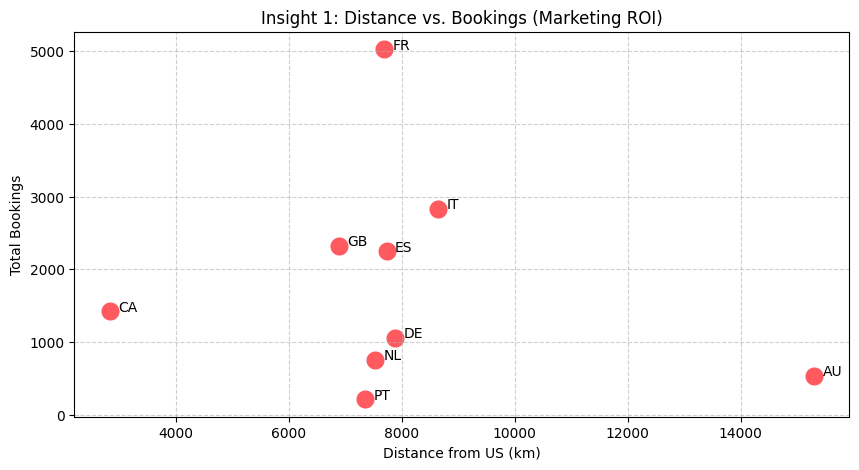

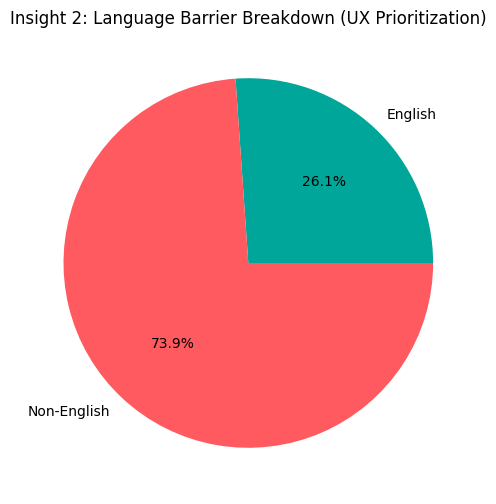

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- SETUP: Assuming you have df_train and df_countries loaded ---
# Get actual booking counts per country (excluding US and NDF)
travelers = train[(train['country_destination'] != 'NDF') & 
                     (train['country_destination'] != 'US')]
bookings = travelers['country_destination'].value_counts().reset_index()
bookings.columns = ['country_destination', 'total_bookings']

# Merge bookings with the countries data
df_geo = pd.merge(bookings, countries, on='country_destination')


# 📊 Insight 1: Distance vs Booking Volume (The Distance Wall)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_geo, x='distance_km', y='total_bookings', s=200, color='#FF5A5F')
for i in range(df_geo.shape[0]):
    plt.text(df_geo['distance_km'][i] + 150, df_geo['total_bookings'][i], df_geo['country_destination'][i])
plt.title("Insight 1: Distance vs. Bookings (Marketing ROI)")
plt.xlabel("Distance from US (km)")
plt.ylabel("Total Bookings")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 📊 Insight 2: Language Barrier vs Bookings
df_geo['is_english'] = df_geo['destination_language '].apply(lambda x: 'English' if x == 'eng' else 'Non-English')
lang_summary = df_geo.groupby('is_english')['total_bookings'].sum().reset_index()

plt.figure(figsize=(6, 6))
plt.pie(lang_summary['total_bookings'], labels=lang_summary['is_english'], autopct='%1.1f%%', colors=['#00a699', '#FF5A5F'])
plt.title("Insight 2: Language Barrier Breakdown (UX Prioritization)")
plt.show()



# 🗺️ Insight 4: The Executive World Map
# Plotly creates an interactive globe mapping our destinations  
fig = px.scatter_geo(
    df_geo, 
    lat='lat_destination', 
    lon='lng_destination', 
    size='total_bookings',
    hover_name='country_destination',
    color='total_bookings',
    projection='natural earth',
    title="Insight 3: Global Airbnb US Traveler Footprint",
    color_continuous_scale=px.colors.sequential.Plasma
)
fig.show()

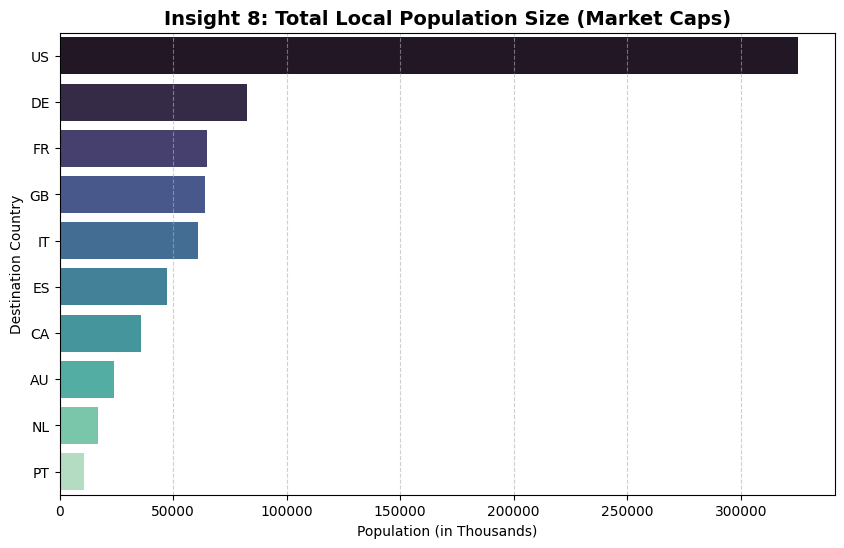

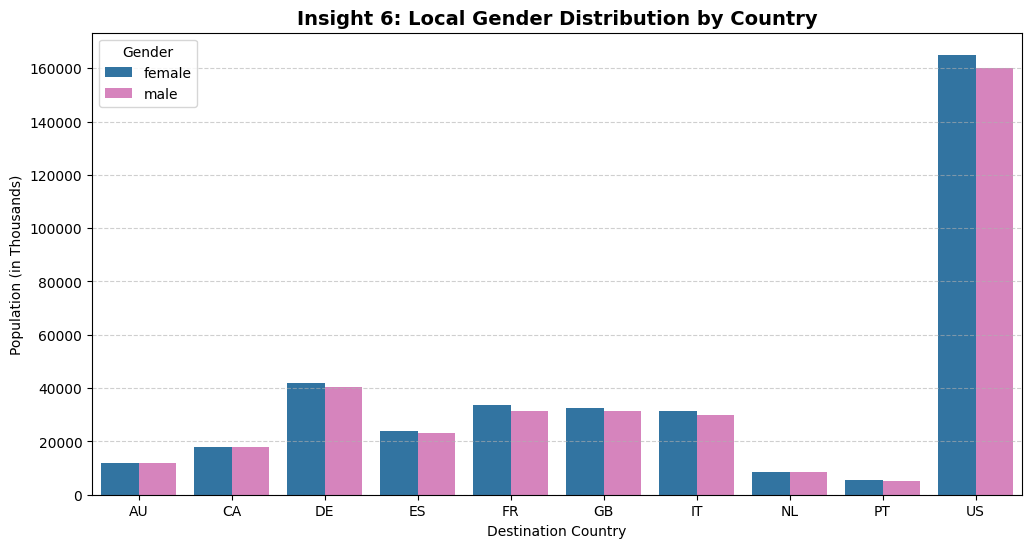

In [36]:

# --- 1. SETUP & CLEANING ---
# (Assuming your dataframe is loaded as 'df_age')
# We drop the 'year' column because every row is from 2015, so it's just noise.
df_age_clean = age_gender.drop(columns=['year'])


# ==============================================================================
# 📊 INSIGHT 8 & 5: Total Local Population Size (Demand Forecasting)
# ==============================================================================

# Sum up all age buckets and both genders to get the total country population
total_pop = df_age_clean.groupby('country_destination')['population_in_thousands'].sum().reset_index()
total_pop = total_pop.sort_values(by='population_in_thousands', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=total_pop, x='population_in_thousands', y='country_destination', palette='mako')

plt.title("Insight 8: Total Local Population Size (Market Caps)", fontsize=14, fontweight='bold')
plt.xlabel("Population (in Thousands)")
plt.ylabel("Destination Country")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


# ==============================================================================
# 📊 INSIGHT 6: Gender Distribution by Country (Personalization)
# ==============================================================================

# Group by both country and gender
gender_split = df_age_clean.groupby(['country_destination', 'gender'])['population_in_thousands'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=gender_split, x='country_destination', y='population_in_thousands', hue='gender', palette=['#1f77b4', '#e377c2'])

plt.title("Insight 6: Local Gender Distribution by Country", fontsize=14, fontweight='bold')
plt.xlabel("Destination Country")
plt.ylabel("Population (in Thousands)")
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
